In [1]:
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Create synthetic classification dataset

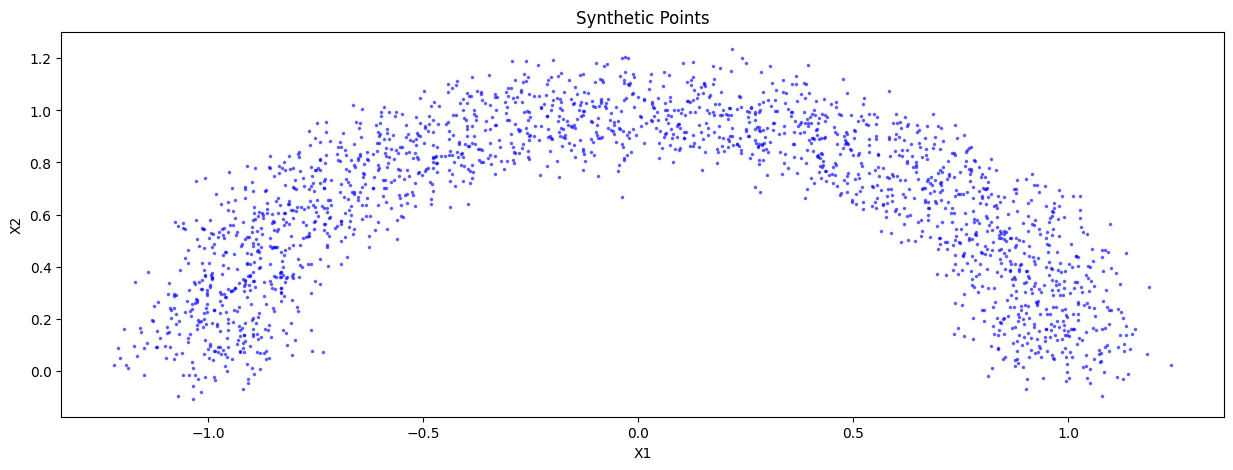

In [2]:
def generate_moon(n_samples=500, radius=1.0, width=0.3, distance=0.1, noise=0.05, flip=False):
    angles = np.linspace(0, np.pi, n_samples)
    r = radius + width * (np.random.rand(n_samples) - 0.5)
    x = r * np.cos(angles)
    y = r * np.sin(angles)

    if flip:
        x = -x + radius  # flip and shift right
        y = -y + distance  # shift down

    x += np.random.normal(0, noise, n_samples)
    y += np.random.normal(0, noise, n_samples)

    x = torch.from_numpy(x).float()
    y = torch.from_numpy(y).float()
    return torch.column_stack([x,y])






def generate_x_points(n_samples=1000):
    """
    Generate n_samples points in the simplex.
    """
    # Generate random points in the simplex
    # Generate both moons
    moon1 = generate_moon(n_samples)
    points = torch.concatenate([moon1], dim=0).numpy()
    return points

# visualize the points
def visualize_points(points):
    """
    Visualize the points in the simplex.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    ax.scatter(points[:,0], points[:,1], marker='.', s=10, alpha=0.5, color='blue')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.show()

# Generate points
point_bunch = generate_x_points()
point_bunch2 = generate_x_points()
data = np.concatenate((point_bunch,point_bunch2),axis=0).astype(np.float32)
# Visualize points
visualize_points(data)

# Define True Target Probability Distribution

In [3]:
# define 1st order probability distribution

def generate_y_probs(points):

    probs = 1 / (1 + torch.exp(-points[:,0]))  # sharper boundary with higher factor
    y_probs = torch.stack([1-probs, probs], dim=-1)
    return y_probs.clip(1e-8,(9999999)/1e7)

def generate_target_and_probs(points):
    y_probs = generate_y_probs(points)
    y_labels = torch.argmax(y_probs, dim=1)
    return y_labels, y_probs

y_labels, y_probs = generate_target_and_probs(torch.tensor(data))
y_probs

tensor([[0.2426, 0.7574],
        [0.2901, 0.7099],
        [0.2990, 0.7010],
        ...,
        [0.7345, 0.2655],
        [0.7324, 0.2676],
        [0.7448, 0.2552]])

# Define Ensemble

In [4]:
from epiuc.uncertainty.classification import MLP_Classifier
from epiuc.uncertainty.wrapper import Ensemble_Classifier
ENSEMBLE_MEMBER_COUNT = 20
base_ensemble = [MLP_Classifier(input_shape=2,n_classes=2,n_layers=2,num_neurons=64,dropout_prob=0,batch_norm=False,) for  _ in range(ENSEMBLE_MEMBER_COUNT)]
ensemble_model = Ensemble_Classifier(base_ensemble,n_models=ENSEMBLE_MEMBER_COUNT)
ensemble_model.load("../models/Ensemble_One_moon/")

In [5]:
def ensemble_probs(points):
    probs,_ = ensemble_model.predict(points,raw_output=True)
    return probs
y_probs_ensemble_points = ensemble_probs(data)
y_pred_ensemble_points = y_probs_ensemble_points.mean(dim=1).argmax(dim=1)

In [6]:
def total_uncertainty_ensemble(y_probs_ensemble):
    y_probs_mean = y_probs_ensemble.mean(dim=1)
    return y_probs_mean.mul(y_probs_mean.log2()).sum(dim=-1).mul(-1)

def aleatoric_uncertainty_ensemble(y_probs_ensemble):
    return y_probs_ensemble.mul(y_probs_ensemble.log2()).sum(dim=-1).mul(-1).mean(dim=1)

def epistemic_uncertainty_ensemble(y_probs_ensemble):
    return (total_uncertainty_ensemble(y_probs_ensemble) - aleatoric_uncertainty_ensemble(y_probs_ensemble)).clip(0,1)

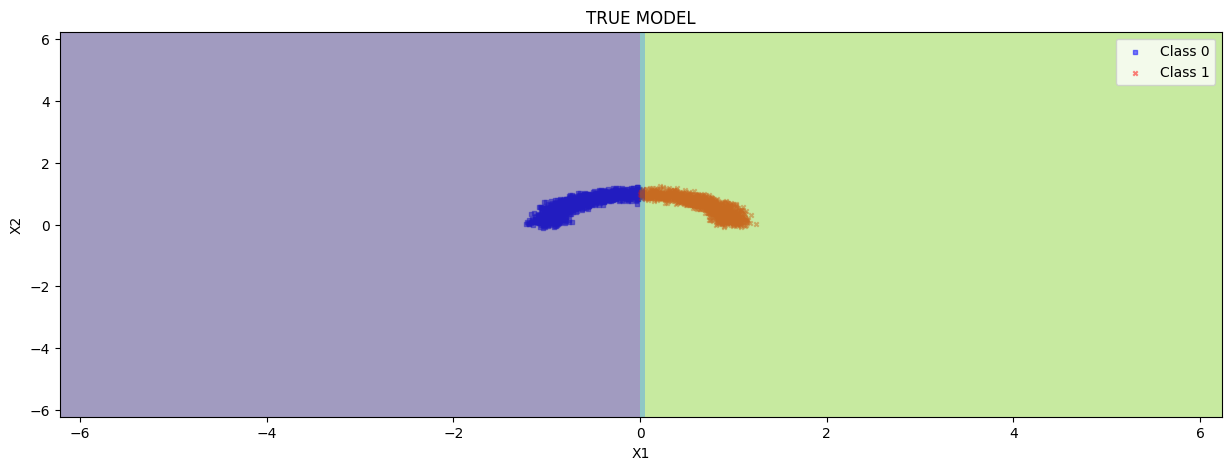

In [7]:
# visualize the labels distribution for the points
def visualize_labels_distribution(points,y_labels):
     # Create gird of points
    grid_points = np.linspace(points.min()-5, points.max()+5, 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    grid_y_labels,_ = generate_target_and_probs(torch.tensor(grid_points))
    gird_y_labels = grid_y_labels.numpy()

    # Plot the points
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # Plot TU
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.contourf(xx, yy, grid_y_labels.reshape(xx.shape),levels=2, alpha=0.5)
    ax.set_title("TRUE MODEL")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")

    plt.legend()
    plt.show()

visualize_labels_distribution(data,y_labels)

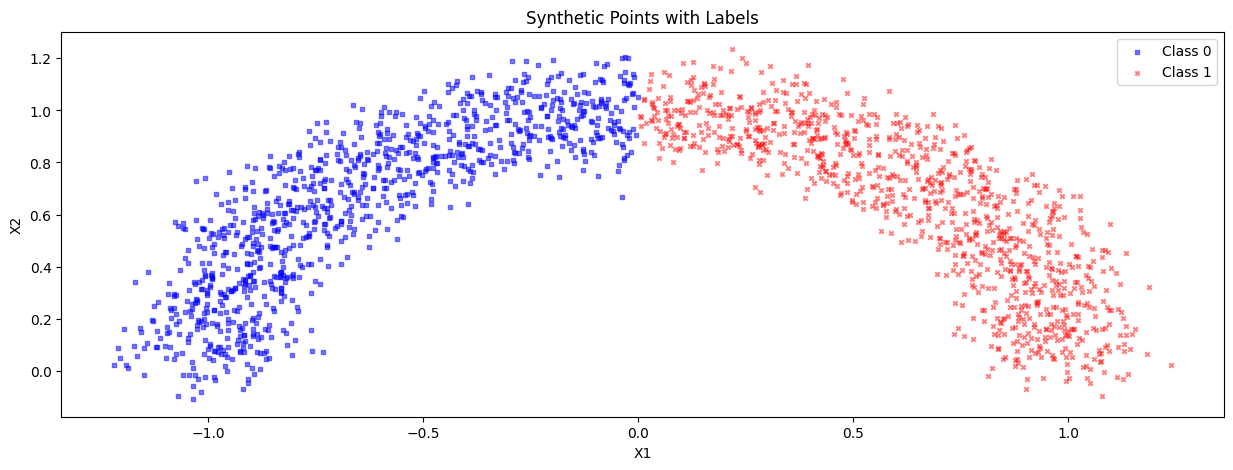

In [8]:
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points with Labels")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()

# Visualize points and labels
visualize_points_and_labels(data, y_labels)

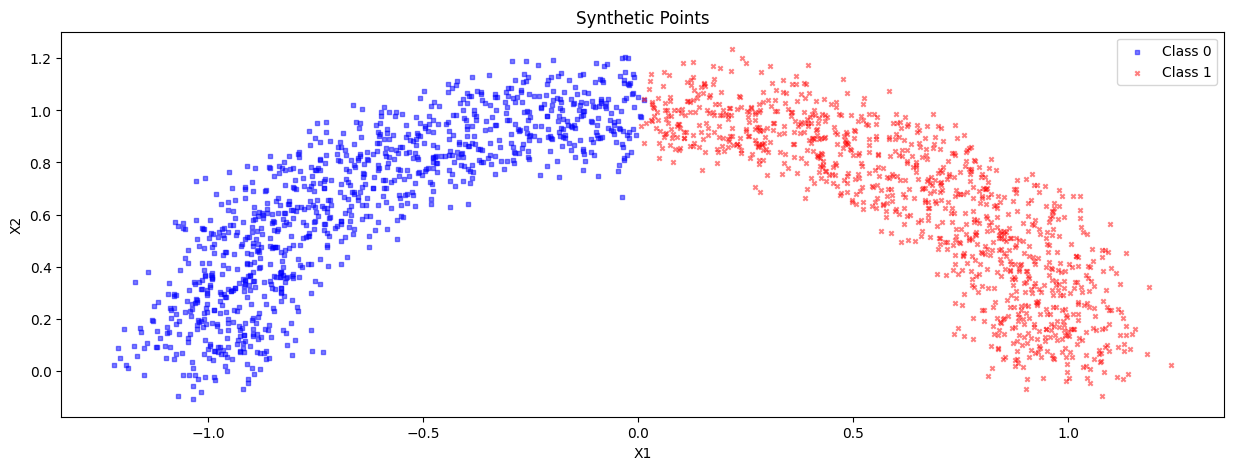

In [9]:
# visualize predictions of the ensemble
# Visualize the points and the labels
def visualize_points_and_labels(points, y_labels):
    """
    Visualize the points and the labels.
    """
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
    # Plot class 0
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
    # Plot class 1
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')
    ax.set_title("Synthetic Points")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    plt.legend()
    plt.show()


# Visualize points and labels
visualize_points_and_labels(data, y_pred_ensemble_points)


torch.Size([10000, 20, 2])
tensor(0.0029, grad_fn=<MinBackward1>) tensor(1.0000, grad_fn=<MaxBackward1>)


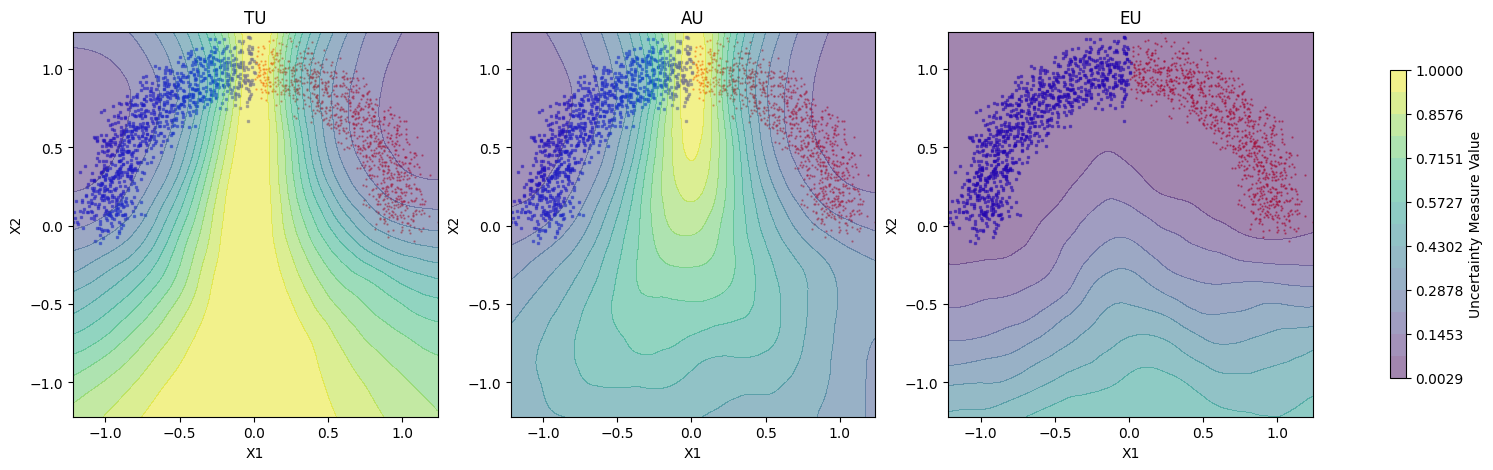

In [10]:
# Look at a given point and AU,EU,TU
def visualize_au_eu_tu_points(points,y_labels):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T
    # Get the labels of the grid_points
    y_probs_ensemble = ensemble_probs(torch.tensor(grid_points, dtype=torch.float32))
    print(y_probs_ensemble.shape)
    total_uncertainty = total_uncertainty_ensemble(y_probs_ensemble)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(y_probs_ensemble)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(y_probs_ensemble)

    # Shared value range
    all_vals = torch.concatenate([total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 5))

    plots = []
    for ax, values, title in zip(axes, [total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty], ["TU", "AU", "EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='.', s=2, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, values.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_eu_tu_points(data,y_pred_ensemble_points)

In [11]:
def sample_delta_ball(reference_point, delta, n_points):
    """
    :param point:
    :param delta:
    :param norm:
    :return:
    """
    delta_samples = []
    for _ in range(n_points):
        sample = np.random.randn(*reference_point.shape)
        sample /= np.linalg.norm(sample,ord=2,axis=-1, keepdims=True)
        delta_sample = sample  * delta
        delta_samples.append([delta_sample])
    samples = np.concatenate(delta_samples,axis=0)
    delta_samples = (reference_point + samples).astype(np.float32)
    return torch.tensor(delta_samples.reshape(-1,2)).requires_grad_(True)

tensor(7.7358e-05, grad_fn=<MinBackward1>) tensor(0.5894, grad_fn=<MaxBackward1>)


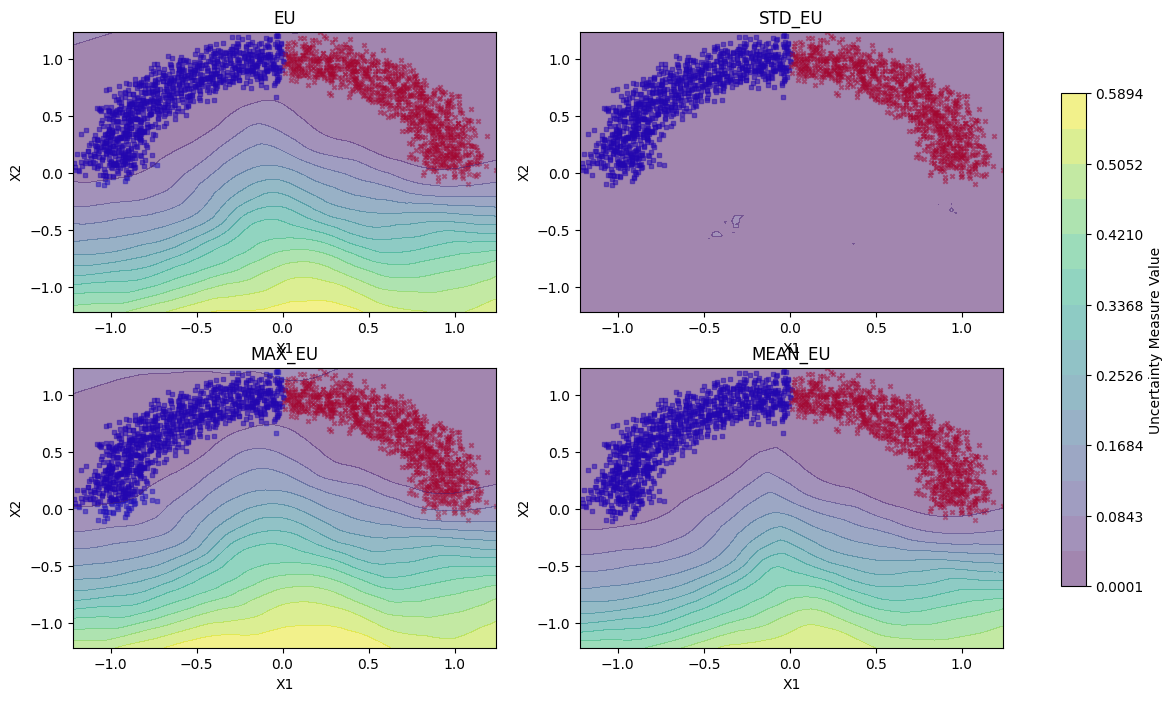

In [12]:
# visualize how std of eu looks like aroung the points
def visualize_eu_std_points(points,y_labels, delta=1, n_points=10):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points, dtype=torch.float32)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    epistemic_uncertainty = epistemic_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),delta,n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    eu_delta_ball = epistemic_uncertainty_ensemble(probs_ensemble_delta_ball).view(n_points,-1)


    std_eu_ball = torch.std(eu_delta_ball,dim=0)
    max_eu_ball = torch.max(eu_delta_ball,dim=0)[0]
    min_eu_ball = torch.min(eu_delta_ball,dim=0)[0]
    mean_eu_ball = torch.mean(eu_delta_ball,dim=0)


    # Shared value range
    all_vals = torch.concatenate([std_eu_ball, epistemic_uncertainty, max_eu_ball, mean_eu_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

    plots = []
    for ax, data, title in zip(axes.flatten(), [epistemic_uncertainty, std_eu_ball, max_eu_ball, min_eu_ball], ["EU","STD_EU", "MAX_EU", "MEAN_EU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_eu_std_points(data,y_pred_ensemble_points,delta=0.1,n_points=100)

tensor(0.0036, grad_fn=<MinBackward1>) tensor(0.9953, grad_fn=<MaxBackward1>)


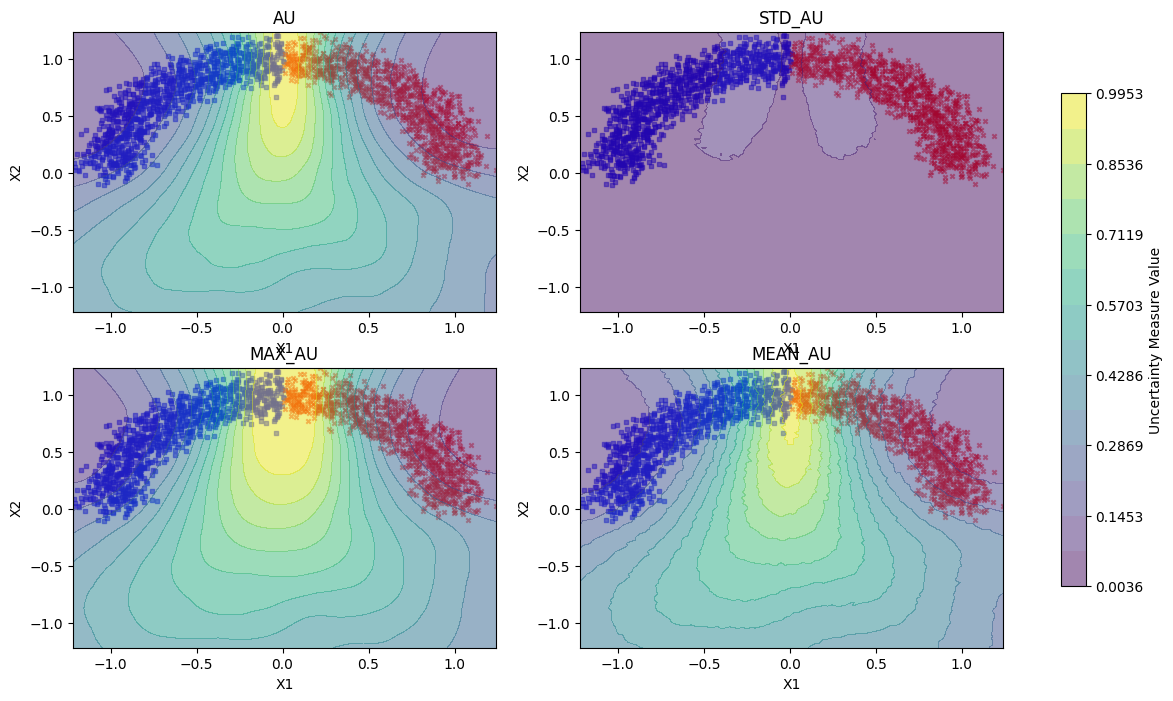

In [13]:
# visualize how std of eu looks like aroung the points
def visualize_au_std_points(points,y_labels, delta=1, n_points=10):
    """
    Visualize a given point and its AU, EU, and TU.
    """
    # Create gird of points
    grid_points = np.linspace(points.min(), points.max(), 100)
    xx,yy = np.meshgrid(grid_points, grid_points)
    grid_points = np.array([xx.flatten(), yy.flatten()]).T

    # Extract loss value
    tensor_points = torch.tensor(grid_points, dtype=torch.float32)
    probs_ensemble  = ensemble_probs(tensor_points)
    probs = probs_ensemble.mean(dim=0)
    aleatoric_uncertainty = aleatoric_uncertainty_ensemble(probs_ensemble)


    # sample_ball
    delta_ball = sample_delta_ball(tensor_points.detach().numpy(),delta,n_points)
    probs_ensemble_delta_ball = ensemble_probs(delta_ball.view(-1,2))
    probs_delta_ball = probs_ensemble_delta_ball.mean(dim=0)
    au_delta_ball = aleatoric_uncertainty_ensemble(probs_ensemble_delta_ball).view(n_points,-1)



    std_au_ball = torch.std(au_delta_ball,dim=0)
    max_au_ball = torch.max(au_delta_ball,dim=0)[0]
    min_au_ball = torch.min(au_delta_ball,dim=0)[0]
    mean_au_ball = torch.mean(au_delta_ball,dim=0)

    # Shared value range
    all_vals = torch.concatenate([std_au_ball, aleatoric_uncertainty, max_au_ball, mean_au_ball], dim=0)
    vmin = all_vals.min()
    vmax = all_vals.max()
    print(vmin, vmax)

    # Define shared levels and normalization
    levels = torch.linspace(vmin, vmax, 15)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = mpl.cm.viridis

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))

    plots = []
    for ax, data, title in zip(axes.flatten(), [aleatoric_uncertainty, std_au_ball, max_au_ball, mean_au_ball], ["AU","STD_AU", "MAX_AU", "MEAN_AU"]):
        # Scatter data
        ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=10, alpha=0.5, color='blue', label='Class 0')
        ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='x', s=10, alpha=0.5, color='red', label='Class 1')

        # Unified contourf
        contour = ax.contourf(xx, yy, data.detach().numpy().reshape(xx.shape), levels=levels, cmap=cmap, norm=norm, alpha=0.5)
        plots.append(contour)

        ax.set_title(title)
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Single shared colorbar using one of the contour handles
    fig.colorbar(plots[0], ax=axes.ravel().tolist(), shrink=0.8, label="Uncertainty Measure Value")

    plt.show()
visualize_au_std_points(data,y_pred_ensemble_points,delta=0.1,n_points=100)

# CF construction

In [14]:
DESIRED_VALIDITY = 0.999
DELTA = 0.1
LAMBDA_1 = 1
LAMBDA_2 = 1
MAX_STEPS = 2000
desired_class=1
#point_of_interest = torch.tensor(np.array([-1,0]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest = torch.tensor(np.array([-1, 0]).reshape(-1,2), dtype=torch.float,requires_grad=True)
point_of_interest_label = torch.tensor(np.array([0]))


## Validity
We now work in the scenario of creating a valid counter factual for our point x

In [15]:
from property_procedures.valid import validity_procedure
from property_procedures.utils import ensemble_probs, aleatoric_uncertainty_ensemble, epistemic_uncertainty_ensemble

cf_valid, cf_steps_valid = validity_procedure(ensemble_model, point_of_interest,probability_function=ensemble_probs,desired_class=desired_class, MAX_STEPS=MAX_STEPS, lambda_1=LAMBDA_1, lambda_2=LAMBDA_2 )

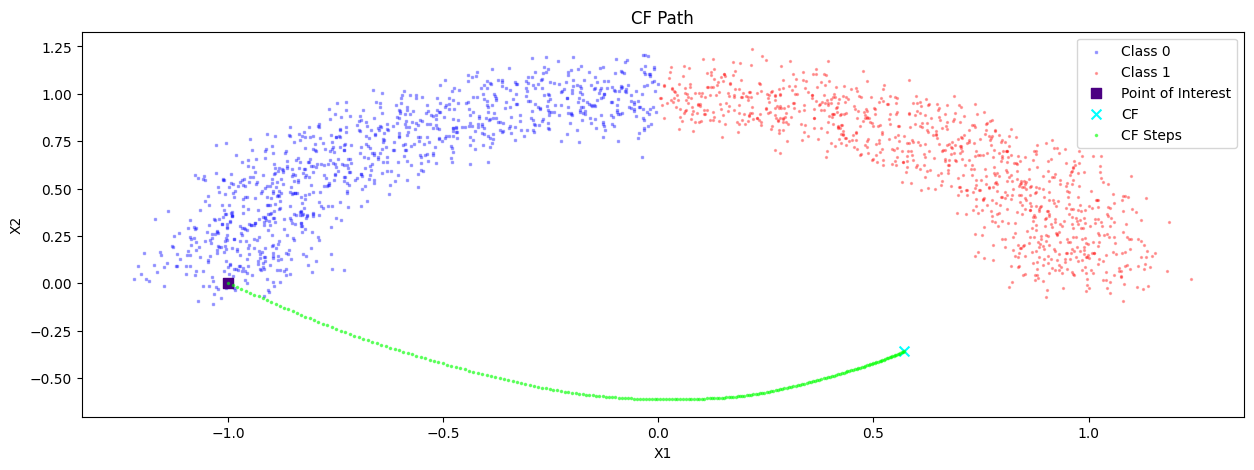

In [16]:
def visualize_cf_and_steps(cf,cf_steps, points, y_labels):
    fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))

    # visualize the data itself
    ax.scatter(points[y_labels == 0, 0], points[y_labels == 0, 1], marker='s', s=2, alpha=0.3, color='blue', label='Class 0')
    ax.scatter(points[y_labels == 1, 0], points[y_labels == 1, 1], marker='o', s=2, alpha=0.3, color='red', label='Class 1')

    ax.scatter(point_of_interest[:,0].detach(), point_of_interest[:,1].detach(), marker='s', s=50, alpha=1, color='indigo', label="Point of Interest")

    ax.scatter(cf[:,0], cf[:,1], marker='x', s=50, color='aqua', label="CF")

    ax.scatter(cf_steps[:,0], cf_steps[:,1], marker='.', s=10, alpha=0.5, color='lime', label="CF Steps")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title("CF Path")

    plt.legend()
visualize_cf_and_steps(cf_valid, cf_steps_valid, data, y_labels)

## Plausability

In [17]:
from property_procedures.plausable import  plausability_procedure

cf_plausable, cf_steps_plausable = plausability_procedure(ensemble_model, point_of_interest,probability_function=ensemble_probs, epistemic_uncertainty_function=epistemic_uncertainty_ensemble, desired_class=desired_class, MAX_STEPS=MAX_STEPS, lambda_1=LAMBDA_1, lambda_2=LAMBDA_2 )

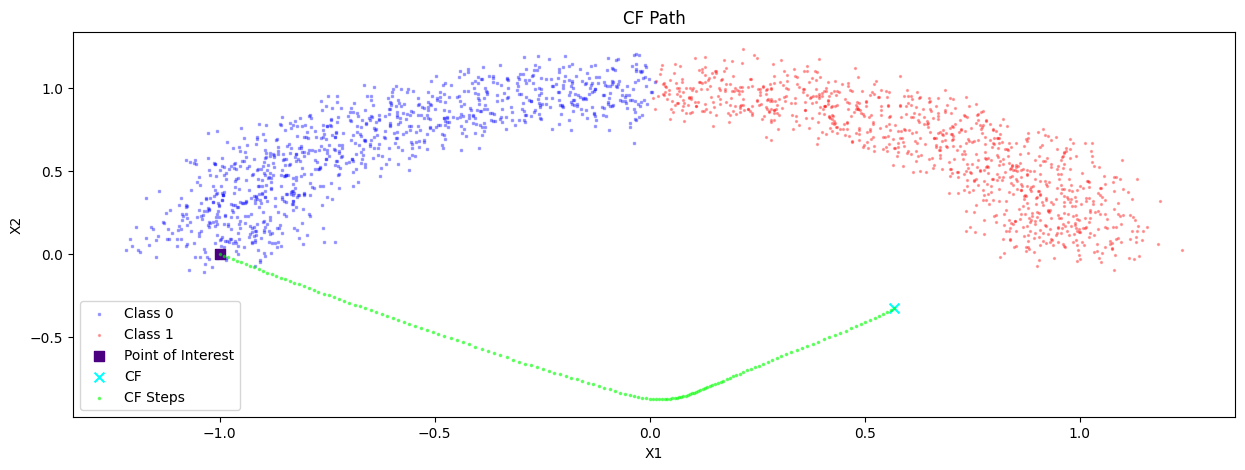

In [18]:
visualize_cf_and_steps(cf_plausable, cf_steps_plausable, data, y_pred_ensemble_points)

In [19]:
cf_plausable, cf_valid

(tensor([[ 0.5688, -0.3249]]), tensor([[ 0.5712, -0.3595]]))

In [20]:
epistemic_uncertainty_ensemble(ensemble_probs(ensemble_model, cf_plausable)), epistemic_uncertainty_ensemble(ensemble_probs(ensemble_model, cf_valid))

(tensor([0.2013], grad_fn=<ClampBackward1>),
 tensor([0.2118], grad_fn=<ClampBackward1>))

## Discrimitiveness

In [21]:
from property_procedures.discriminative import  discriminiative_procedure

cf_discriminiative, cf_steps_discriminiative = discriminiative_procedure(ensemble_model, point_of_interest,probability_function=ensemble_probs, aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble, desired_class=desired_class, MAX_STEPS=MAX_STEPS, lambda_1=LAMBDA_1, lambda_2=LAMBDA_2)

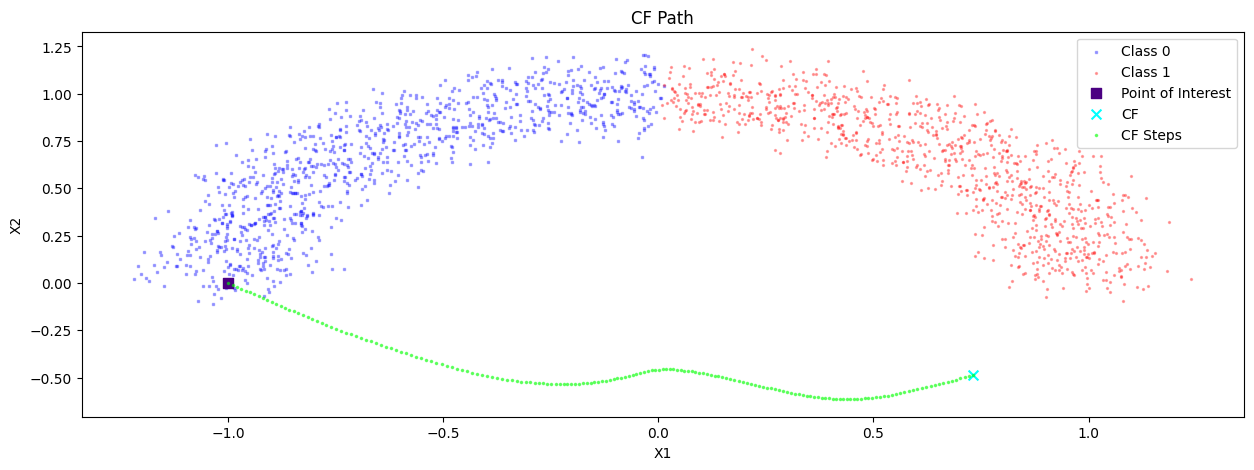

In [22]:
visualize_cf_and_steps(cf_discriminiative, cf_steps_discriminiative, data, y_pred_ensemble_points)


In [23]:
cf_discriminiative, cf_plausable, cf_valid

(tensor([[ 0.7305, -0.4859]]),
 tensor([[ 0.5688, -0.3249]]),
 tensor([[ 0.5712, -0.3595]]))

In [24]:
aleatoric_uncertainty_ensemble(ensemble_probs(ensemble_model, cf_plausable)), aleatoric_uncertainty_ensemble(ensemble_probs(ensemble_model, cf_valid)), aleatoric_uncertainty_ensemble(ensemble_probs(ensemble_model, cf_discriminiative))


(tensor([0.5031], grad_fn=<MulBackward0>),
 tensor([0.5066], grad_fn=<MulBackward0>),
 tensor([0.4494], grad_fn=<MulBackward0>))

## Robustness

In [25]:
from property_procedures.robust import robust_procedure

cf_robust, cf_steps_robust = robust_procedure(ensemble_model, point_of_interest,
                                              probability_function=ensemble_probs, aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
                                              epistemic_uncertainty_function=epistemic_uncertainty_ensemble, desired_class=desired_class, delta=DELTA,
                                              MAX_STEPS=MAX_STEPS, lambda_1=LAMBDA_1, lambda_2=LAMBDA_2)

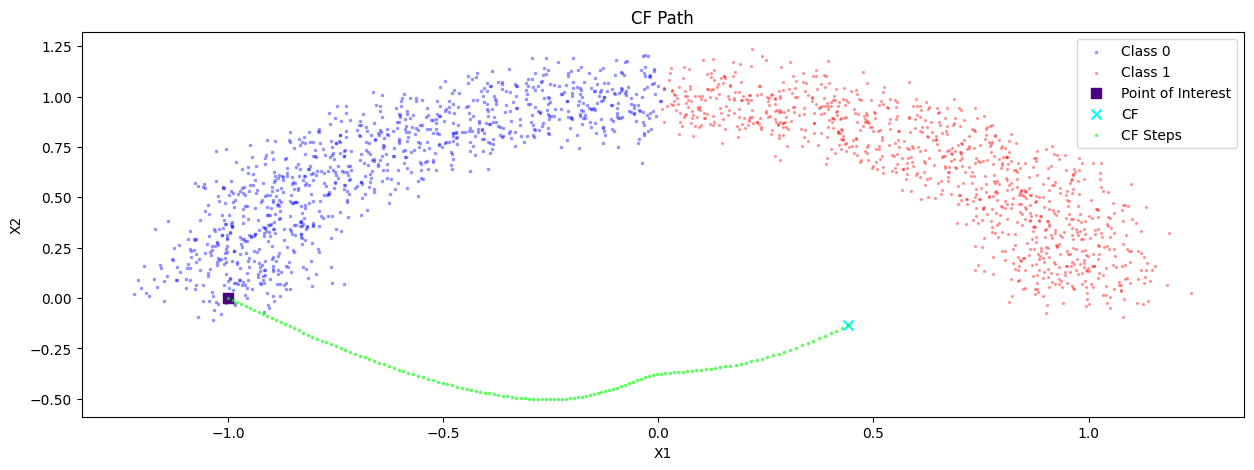

In [26]:
visualize_cf_and_steps(cf_robust,cf_steps_robust, data, y_pred_ensemble_points)

In [27]:
cf_robust, cf_plausable

(tensor([[ 0.4407, -0.1339]]), tensor([[ 0.5688, -0.3249]]))

In [28]:
epistemic_uncertainty_ensemble(ensemble_probs(ensemble_model, cf_robust)), epistemic_uncertainty_ensemble(ensemble_probs(ensemble_model, cf_plausable))

(tensor([0.1489], grad_fn=<ClampBackward1>),
 tensor([0.2013], grad_fn=<ClampBackward1>))

In [29]:

res_mean = []
res_std = []
for _ in range(10):
    delta_cf_robust = sample_delta_ball(cf_robust.detach().numpy(), delta=0.2, n_points=100)
    epistemic_cf_robust = []
    for point in delta_cf_robust:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_robust.append(
            epistemic_uncertainty_ensemble(ensemble_probs(ensemble_model, point.view(-1,2))).detach().numpy()
        )

    delta_cf_plausable = sample_delta_ball(cf_plausable.detach().numpy(), delta=0.2, n_points=100)
    epistemic_cf_plausable = []
    for point in delta_cf_plausable:
        #visualize_cf_and_steps(cf_point, cf_steps_point, points, y_pred_ensemble_points)
        epistemic_cf_plausable.append(
            epistemic_uncertainty_ensemble(ensemble_probs(ensemble_model, point.view(-1,2))).detach().numpy()
        )

    print("Std Epistemic Uncertainty of Robust Procedure: ",np.mean(epistemic_cf_robust) , " +/- " ,  np.std(epistemic_cf_robust))
    print("Std Epistemic Uncertainty of Plausable Procedure: ", np.mean(epistemic_cf_plausable) , " +/- " , np.std(epistemic_cf_plausable))

    res_mean.append([np.mean(epistemic_cf_robust), np.mean(epistemic_cf_plausable)])
    res_std.append([np.std(epistemic_cf_robust), np.std(epistemic_cf_plausable)])

np.mean(res_mean,axis=0), np.std(res_mean,axis=0), np.mean(res_std,axis=0), np.std(res_std,axis=0)

Std Epistemic Uncertainty of Robust Procedure:  0.1478378  +/-  0.04559582
Std Epistemic Uncertainty of Plausable Procedure:  0.21176858  +/-  0.053891443
Std Epistemic Uncertainty of Robust Procedure:  0.1536991  +/-  0.04631062
Std Epistemic Uncertainty of Plausable Procedure:  0.19724898  +/-  0.052644096
Std Epistemic Uncertainty of Robust Procedure:  0.15415166  +/-  0.046725564
Std Epistemic Uncertainty of Plausable Procedure:  0.21276078  +/-  0.054401
Std Epistemic Uncertainty of Robust Procedure:  0.14580473  +/-  0.047007766
Std Epistemic Uncertainty of Plausable Procedure:  0.21610633  +/-  0.050144
Std Epistemic Uncertainty of Robust Procedure:  0.15474835  +/-  0.04647988
Std Epistemic Uncertainty of Plausable Procedure:  0.20200098  +/-  0.053150646
Std Epistemic Uncertainty of Robust Procedure:  0.15512115  +/-  0.047704138
Std Epistemic Uncertainty of Plausable Procedure:  0.20436516  +/-  0.051836826
Std Epistemic Uncertainty of Robust Procedure:  0.16022599  +/-  0.04

(array([0.15261677, 0.20425221], dtype=float32),
 array([0.00479913, 0.00673945], dtype=float32),
 array([0.04632912, 0.05265554], dtype=float32),
 array([0.00087425, 0.00122698], dtype=float32))

## Connectednss

In [30]:
from property_procedures.connected import connected_ball_procedure

cf_connected, cf_steps_connected= connected_ball_procedure(ensemble_model, point_of_interest,probability_function=ensemble_probs,
                                                           delta=DELTA,
                                                           aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble, epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
                                                           desired_class=desired_class, MAX_STEPS=MAX_STEPS,
                                                           lambda_1=LAMBDA_1, lambda_2=LAMBDA_2)

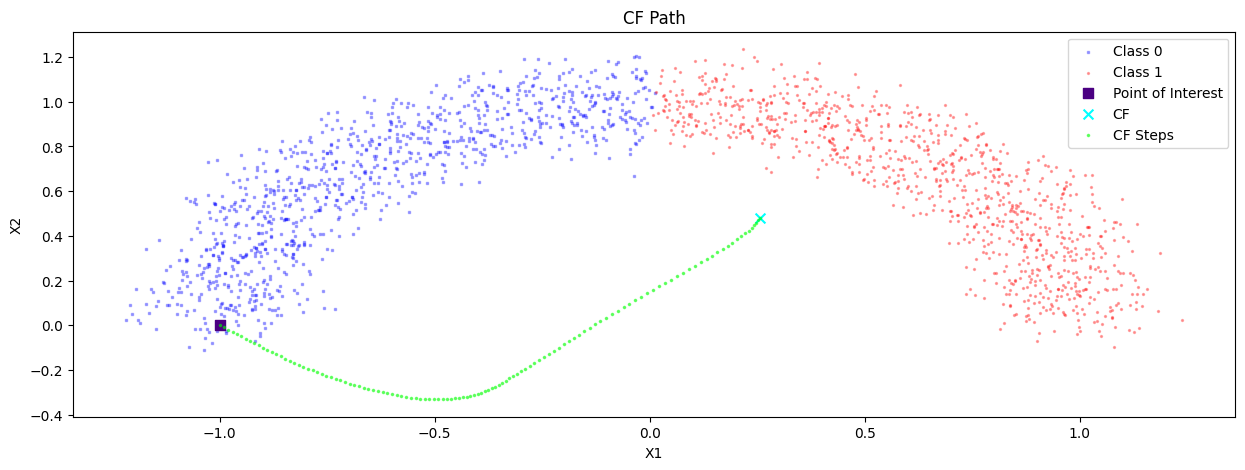

In [31]:
visualize_cf_and_steps(cf_connected,cf_steps_connected, data, y_pred_ensemble_points)

In [32]:
from property_procedures.connected import connectedness_procedure
# Choose as reference point the point with highest probability for this class in the dataset
with torch.no_grad():
        probs_reference = ensemble_probs(ensemble_model, torch.tensor(data)).mean(dim=1)[:,desired_class]
        idx_reference = np.argmax(probs_reference)
        reference_point = torch.tensor(data[idx_reference])
print(reference_point)

cf_connected_au, cf_steps_connected_au = connectedness_procedure(ensemble_model, point_of_interest,
                                                                 reference_point=reference_point,
                                                                 probability_function=ensemble_probs,
                                                           aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble, epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
                                                           desired_class=desired_class, MAX_STEPS=MAX_STEPS,
                                                           lambda_1=LAMBDA_1, lambda_2=LAMBDA_2)

tensor([1.0982, 0.5648])


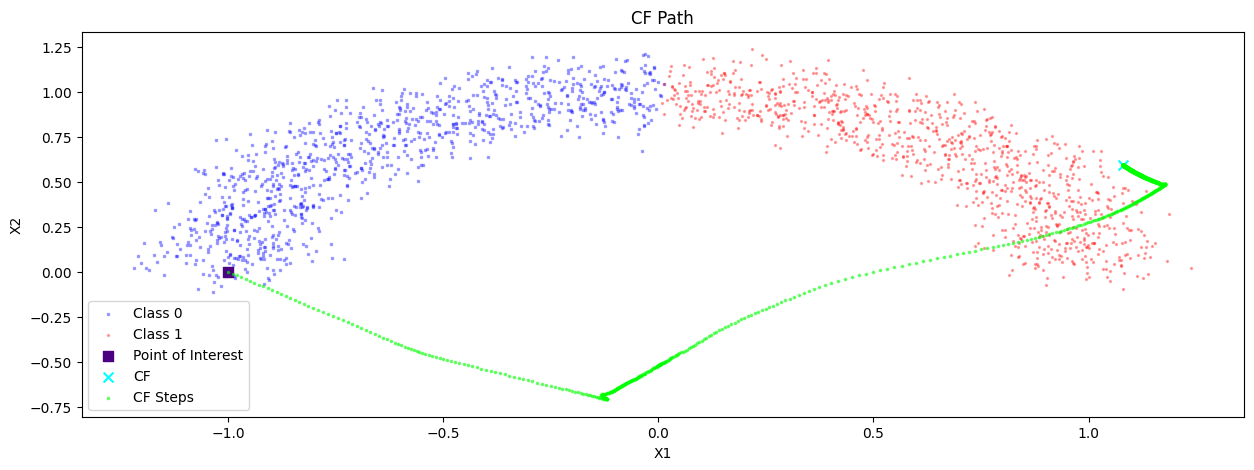

In [33]:
visualize_cf_and_steps(cf_connected_au,cf_steps_connected_au, data, y_pred_ensemble_points)

## Similarity

In [34]:
from property_procedures.similarity import similiarity_procedure

cf_similiar, cf_steps_similiar = similiarity_procedure(ensemble_model, point_of_interest,probability_function=ensemble_probs,
                                                           aleatoric_uncertainty_function=aleatoric_uncertainty_ensemble,
                                                        delta=DELTA,
                                                           desired_class=desired_class, MAX_STEPS=MAX_STEPS,
                                                           lambda_1=LAMBDA_1, lambda_2=LAMBDA_2)

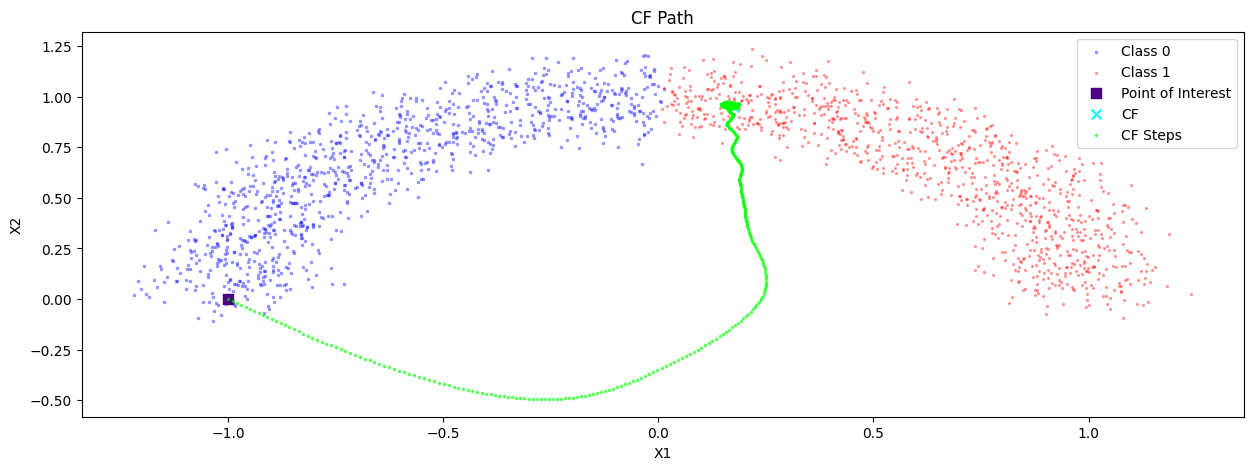

In [35]:
visualize_cf_and_steps(cf_similiar,cf_steps_similiar, data, y_pred_ensemble_points)

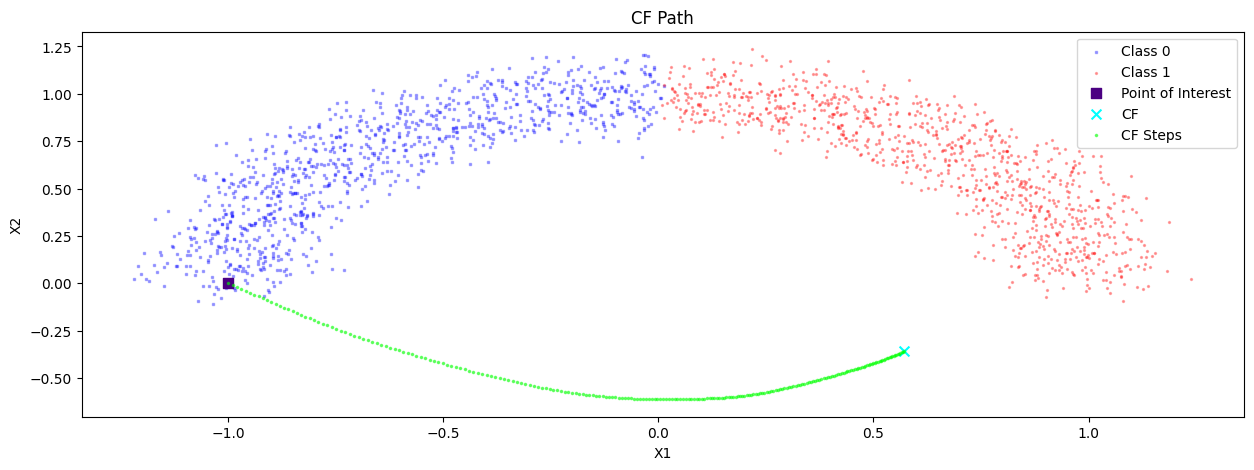

In [36]:
visualize_cf_and_steps(cf_valid,cf_steps_valid, data, y_pred_ensemble_points)

In [37]:
cf_similiar, cf_valid
print(point_of_interest)
torch.linalg.norm(cf_similiar - point_of_interest, ord=2),torch.linalg.norm(cf_valid - point_of_interest, ord=2)

tensor([[-1.,  0.]], requires_grad=True)


(tensor(1.5103, grad_fn=<AmaxBackward0>),
 tensor(1.6118, grad_fn=<AmaxBackward0>))

## Feasability

In [38]:
from property_procedures.feasable import feasability_procedure

cf_feasable_eu, cf_steps_feasable_eu = feasability_procedure(ensemble_model, point_of_interest,probability_function=ensemble_probs,
                                                            epistemic_uncertainty_function=epistemic_uncertainty_ensemble,
                                                           desired_class=desired_class, MAX_STEPS=MAX_STEPS,
                                                           lambda_1=LAMBDA_1, lambda_2=LAMBDA_2)

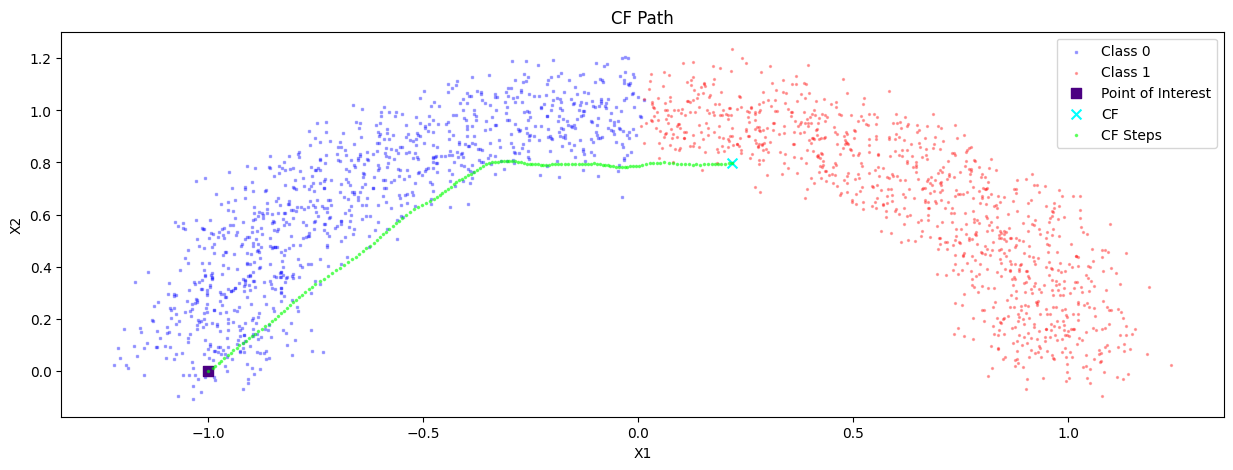

In [39]:
visualize_cf_and_steps(cf_feasable_eu, cf_steps_feasable_eu, data, y_pred_ensemble_points)